# HW10-11 – Компьютерное зрение в PyTorch: CNN, Transfer Learning, Сегментация

## 0. Импорты, seed и устройство

In [3]:
%matplotlib inline
import os, json, csv
import numpy as np
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import STL10, OxfordIIITPet
from PIL import Image

# Пути к директориям
BASE = os.path.abspath(".")
ART  = os.path.join(BASE, "artifacts")
FIG  = os.path.join(ART, "figures")
DATA = os.path.join(BASE, "data")
os.makedirs(FIG, exist_ok=True)
os.makedirs(DATA, exist_ok=True)

# Фиксируем seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Выбор устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Часть A: Данные STL10

Загружаем датасет STL10 и создаём три варианта трансформаций:
- `tf_base` — базовая нормализация без аугментаций
- `tf_aug` — с аугментациями (flip, crop, color jitter)
- `tf_resnet` — для ResNet (224×224, нормализация ImageNet)

Разбивка: 80% train / 20% val из обучающей выборки (5000 примеров).

In [4]:
IMG_SIZE    = 64
BATCH       = 64
EPOCHS_A    = 8
NUM_CLASSES = 10

# Базовые трансформации (без аугментаций)
tf_base = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.4467, 0.4398, 0.4066], std=[0.2603, 0.2566, 0.2713]),
])

# Трансформации с аугментациями
tf_aug = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomCrop(IMG_SIZE, padding=8),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.4467, 0.4398, 0.4066], std=[0.2603, 0.2566, 0.2713]),
])

# Трансформации для ResNet (224×224, ImageNet нормализация)
tf_resnet = T.Compose([
    T.Resize(256), T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Загрузка STL10
print("Loading STL10...")
ds_tr_base   = STL10(DATA, split="train", download=True, transform=tf_base)
ds_tr_aug    = STL10(DATA, split="train", download=True, transform=tf_aug)
ds_tr_resnet = STL10(DATA, split="train", download=True, transform=tf_resnet)
ds_te_base   = STL10(DATA, split="test",  download=True, transform=tf_base)
ds_te_resnet = STL10(DATA, split="test",  download=True, transform=tf_resnet)

# Разбивка 80/20 train/val
n = len(ds_tr_base)  # 5000
n_val = int(n * 0.2)
n_tr  = n - n_val    # 4000 / 1000
rng = np.random.RandomState(SEED)
idx_perm = rng.permutation(n)
tr_idx, va_idx = idx_perm[:n_tr].tolist(), idx_perm[n_tr:].tolist()
print(f"STL10: train={n_tr} val={n_val} test={len(ds_te_base)}")

# Функция создания DataLoader-ов
def make_loaders(ds_tr, ds_va_src, ds_te, shuffle_tr=True):
    dl_tr = DataLoader(Subset(ds_tr, tr_idx),     batch_size=BATCH, shuffle=shuffle_tr, num_workers=0)
    dl_va = DataLoader(Subset(ds_va_src, va_idx), batch_size=BATCH, shuffle=False,      num_workers=0)
    dl_te = DataLoader(ds_te,                     batch_size=BATCH, shuffle=False,      num_workers=0)
    return dl_tr, dl_va, dl_te

Loading STL10...


100.0%


STL10: train=4000 val=1000 test=8000


## 2. Sanity-check данных

Проверяем формы батчей и визуализируем несколько примеров из обучающей выборки.

Train batch: x=torch.Size([64, 3, 64, 64]), y=torch.Size([64]), dtype=torch.float32
Val   batch: x=torch.Size([64, 3, 64, 64]), y=torch.Size([64])
Test  batch: x=torch.Size([64, 3, 64, 64]), y=torch.Size([64])


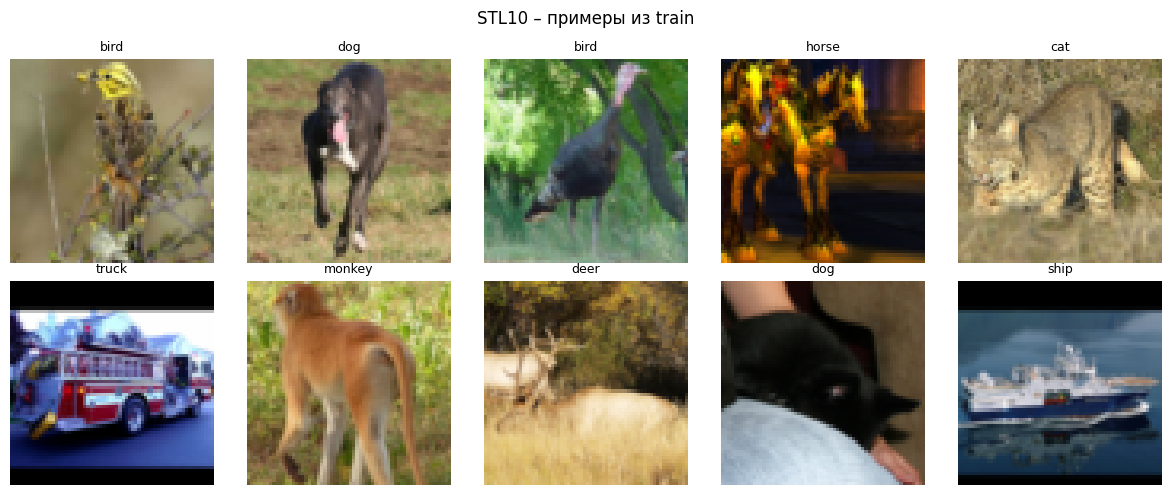

In [5]:
# Создаём временные загрузчики для sanity-check
dl_tr_b, dl_va_b, dl_te_b = make_loaders(ds_tr_base, ds_tr_base, ds_te_base)

xb, yb = next(iter(dl_tr_b))
print(f"Train batch: x={xb.shape}, y={yb.shape}, dtype={xb.dtype}")

xv, yv = next(iter(dl_va_b))
print(f"Val   batch: x={xv.shape}, y={yv.shape}")

xt, yt = next(iter(dl_te_b))
print(f"Test  batch: x={xt.shape}, y={yt.shape}")

# Классы STL10
STL10_CLASSES = ["airplane","bird","car","cat","deer","dog","horse","monkey","ship","truck"]

# Визуализация нескольких примеров
ds_raw = STL10(DATA, split="train", download=True,
               transform=T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()]))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img_t, lbl = ds_raw[i]
    ax.imshow(img_t.permute(1, 2, 0).numpy())
    ax.set_title(STL10_CLASSES[lbl], fontsize=9)
    ax.axis("off")
plt.suptitle("STL10 – примеры из train")
plt.tight_layout()
plt.show()

## 3. Аугментации

Визуализируем эффект аугментаций: оригинал и два варианта преобразований для 6 изображений.
Сохраняем превью в `artifacts/figures/augmentations_preview.png`.

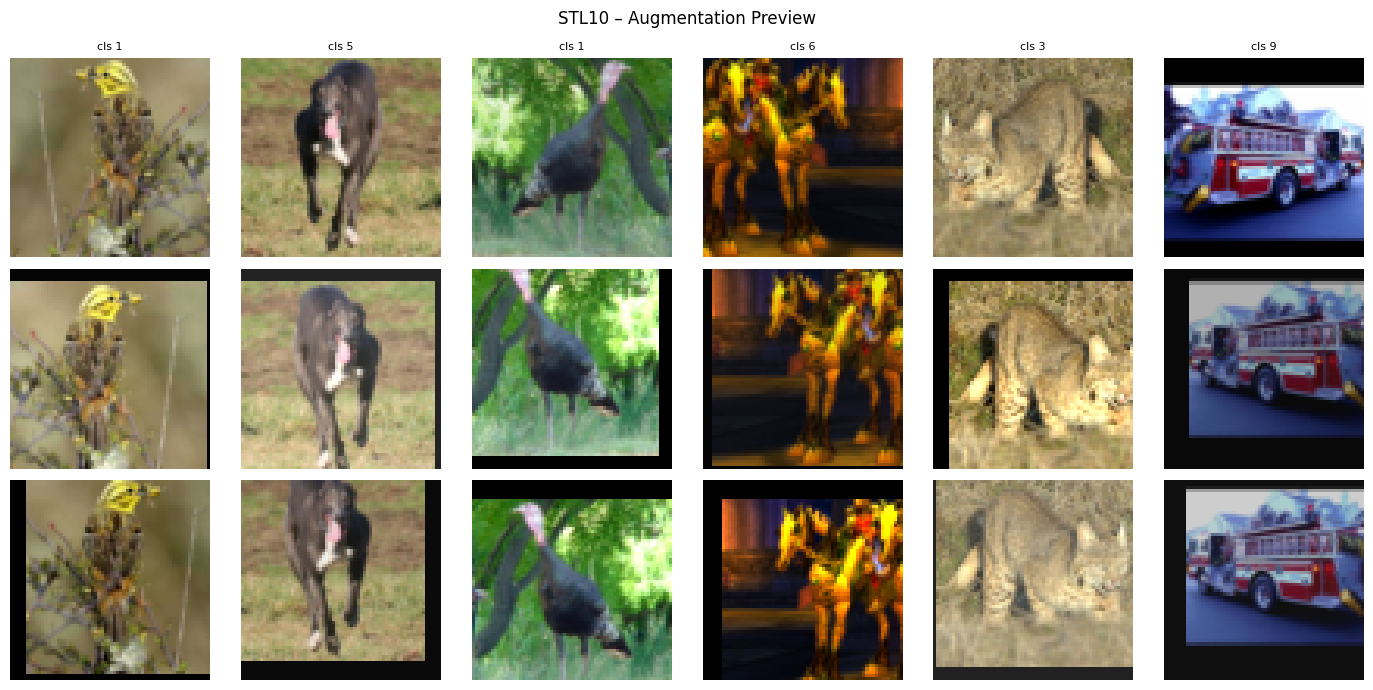

Saved augmentations_preview.png


In [6]:
# Аугментации только (без нормализации) для наглядной визуализации
aug_only = T.Compose([
    T.RandomHorizontalFlip(p=1.0),
    T.RandomCrop(IMG_SIZE, padding=8),
    T.ColorJitter(brightness=0.3, contrast=0.3),
])

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
for col in range(6):
    img_t, lbl = ds_raw[col]
    img_pil = T.ToPILImage()(img_t)
    axes[0, col].imshow(img_pil)
    axes[0, col].set_title(f"cls {lbl}", fontsize=8)
    axes[0, col].axis("off")
    axes[1, col].imshow(aug_only(img_pil))
    axes[1, col].axis("off")
    axes[2, col].imshow(aug_only(img_pil))
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=9)
axes[1, 0].set_ylabel("Aug 1", fontsize=9)
axes[2, 0].set_ylabel("Aug 2", fontsize=9)
plt.suptitle("STL10 – Augmentation Preview")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "augmentations_preview.png"), dpi=100)
plt.show()
print("Saved augmentations_preview.png")

## 4. Модель SimpleCNN

Определяем архитектуру SimpleCNN с 4 свёрточными блоками:
- Каждый блок: `Conv2d → BatchNorm2d → ReLU → Pool`
- Последний блок использует `AdaptiveAvgPool2d(2)` для нормализации размера
- Голова: `Flatten → Linear(1024, 256) → ReLU → Dropout(0.4) → Linear(256, num_classes)`

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            # Блок 1: 3 → 32 каналов, 64×64 → 32×32
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            # Блок 2: 32 → 64 каналов, 32×32 → 16×16
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            # Блок 3: 64 → 128 каналов, 16×16 → 8×8
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            # Блок 4: 128 → 256 каналов, AdaptiveAvgPool → 2×2
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(2),
            # Голова классификатора
            nn.Flatten(),
            nn.Linear(256 * 4, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)

# Быстрая проверка архитектуры
model_test = SimpleCNN(NUM_CLASSES)
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE)
out = model_test(dummy)
print(f"SimpleCNN output shape: {out.shape}")
total_params = sum(p.numel() for p in model_test.parameters())
print(f"Total parameters: {total_params:,}")
del model_test

SimpleCNN output shape: torch.Size([2, 10])
Total parameters: 654,346


## 5. Функции обучения и оценки

- `train_epoch` — один проход по обучающей выборке (forward + backward)
- `eval_epoch` — оценка модели без градиентов
- `run_exp` — полный эксперимент: обучение с `CosineAnnealingLR`, сохранение лучших весов

In [8]:
def train_epoch(model, loader, opt, crit):
    """Один эпох обучения, возвращает (loss, accuracy)."""
    model.train()
    tot_loss = tot_ok = tot = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = model(xb)
        loss = crit(out, yb)
        loss.backward()
        opt.step()
        tot_loss += loss.item() * len(yb)
        tot_ok   += (out.argmax(1) == yb).sum().item()
        tot      += len(yb)
    return tot_loss / tot, tot_ok / tot


def eval_epoch(model, loader, crit):
    """Оценка модели на loader без обновления весов."""
    model.eval()
    tot_loss = tot_ok = tot = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out  = model(xb)
            loss = crit(out, yb)
            tot_loss += loss.item() * len(yb)
            tot_ok   += (out.argmax(1) == yb).sum().item()
            tot      += len(yb)
    return tot_loss / tot, tot_ok / tot


def run_exp(model, dl_tr, dl_va, dl_te, name, epochs=EPOCHS_A, lr=1e-3):
    """Полный цикл обучения эксперимента.
    Возвращает (hist, best_val_acc, test_acc, best_state_dict).
    """
    crit = nn.CrossEntropyLoss()
    opt  = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val = 0.0
    best_st  = None
    print(f"\n=== {name} ===")
    for ep in range(1, epochs + 1):
        tl, ta = train_epoch(model, dl_tr, opt, crit)
        vl, va = eval_epoch(model, dl_va, crit)
        sch.step()
        hist["train_loss"].append(tl)
        hist["val_loss"].append(vl)
        hist["train_acc"].append(ta)
        hist["val_acc"].append(va)
        if va > best_val:
            best_val = va
            best_st  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 2 == 0:
            print(f"  Ep {ep}/{epochs} | tr_acc={ta:.3f} val_acc={va:.3f}")
    model.load_state_dict(best_st)
    _, te_acc = eval_epoch(model, dl_te, crit)
    print(f"  BEST val={best_val:.4f} test={te_acc:.4f}")
    return hist, best_val, te_acc, best_st

## 6. C1 – Simple CNN (без аугментаций)

Базовый эксперимент: SimpleCNN обучается на STL10 без аугментаций.
- Оптимизатор: Adam, lr=1e-3
- Расписание: CosineAnnealingLR
- Эпох: 8

In [9]:
# C1: SimpleCNN без аугментаций
dl_tr_b, dl_va_b, dl_te_b = make_loaders(ds_tr_base, ds_tr_base, ds_te_base)
hist_c1, val_c1, test_c1, st_c1 = run_exp(
    SimpleCNN(NUM_CLASSES).to(device),
    dl_tr_b, dl_va_b, dl_te_b,
    name="C1"
)
print(f"C1 → val={val_c1:.4f}, test={test_c1:.4f}")


=== C1 ===
  Ep 2/8 | tr_acc=0.436 val_acc=0.323
  Ep 4/8 | tr_acc=0.550 val_acc=0.523
  Ep 6/8 | tr_acc=0.638 val_acc=0.594
  Ep 8/8 | tr_acc=0.706 val_acc=0.640
  BEST val=0.6400 test=0.6429
C1 → val=0.6400, test=0.6429


## 7. C2 – Simple CNN + аугментации

SimpleCNN с аугментациями на train: `RandomHorizontalFlip`, `RandomCrop`, `ColorJitter`.
Валидация и тест — без аугментаций.

In [10]:
# C2: SimpleCNN с аугментациями
dl_tr_a, dl_va_a, dl_te_a = make_loaders(ds_tr_aug, ds_tr_base, ds_te_base)
hist_c2, val_c2, test_c2, st_c2 = run_exp(
    SimpleCNN(NUM_CLASSES).to(device),
    dl_tr_a, dl_va_a, dl_te_a,
    name="C2"
)
print(f"C2 → val={val_c2:.4f}, test={test_c2:.4f}")


=== C2 ===
  Ep 2/8 | tr_acc=0.363 val_acc=0.396
  Ep 4/8 | tr_acc=0.473 val_acc=0.473
  Ep 6/8 | tr_acc=0.541 val_acc=0.548
  Ep 8/8 | tr_acc=0.581 val_acc=0.585
  BEST val=0.5850 test=0.5914
C2 → val=0.5850, test=0.5914


## 8. C3 – ResNet18 (head-only)

Transfer learning: ResNet18 предобученный на ImageNet.
- Заморажиаем весь backbone
- Заменяем финальный слой `fc` на `Linear(512, 10)`
- Обучаем только голову классификатора
- Входные изображения 224×224

In [11]:
# C3: ResNet18 – только голова
wts = models.ResNet18_Weights.IMAGENET1K_V1
m_c3 = models.resnet18(weights=wts)
# Замораживаем весь backbone
for p in m_c3.parameters():
    p.requires_grad = False
# Заменяем fc
m_c3.fc = nn.Linear(512, NUM_CLASSES)
m_c3 = m_c3.to(device)

trainable = sum(p.numel() for p in m_c3.parameters() if p.requires_grad)
print(f"C3 обучаемых параметров: {trainable:,}")

dl_tr_r, dl_va_r, dl_te_r = make_loaders(ds_tr_resnet, ds_tr_resnet, ds_te_resnet)
hist_c3, val_c3, test_c3, st_c3 = run_exp(
    m_c3, dl_tr_r, dl_va_r, dl_te_r,
    name="C3", lr=1e-3
)
print(f"C3 → val={val_c3:.4f}, test={test_c3:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\tema/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


C3 обучаемых параметров: 5,130

=== C3 ===
  Ep 2/8 | tr_acc=0.911 val_acc=0.928
  Ep 4/8 | tr_acc=0.941 val_acc=0.944
  Ep 6/8 | tr_acc=0.946 val_acc=0.946
  Ep 8/8 | tr_acc=0.948 val_acc=0.949
  BEST val=0.9490 test=0.9397
C3 → val=0.9490, test=0.9397


## 9. C4 – ResNet18 (partial finetune, layer4+fc)

Частичная дообучение ResNet18:
- Замораживаем слои 1-3
- Разораживаем `layer4` и `fc`
- Меньший learning rate (5e-4) для стабильности

In [12]:
# C4: ResNet18 – частичная дообучение (layer4 + fc)
m_c4 = models.resnet18(weights=wts)
# Замораживаем всё
for p in m_c4.parameters():
    p.requires_grad = False
# Размораживаем layer4
for p in m_c4.layer4.parameters():
    p.requires_grad = True
# Заменяем fc
m_c4.fc = nn.Linear(512, NUM_CLASSES)
m_c4 = m_c4.to(device)

trainable = sum(p.numel() for p in m_c4.parameters() if p.requires_grad)
print(f"C4 обучаемых параметров: {trainable:,}")

hist_c4, val_c4, test_c4, st_c4 = run_exp(
    m_c4, dl_tr_r, dl_va_r, dl_te_r,
    name="C4", lr=5e-4
)
print(f"C4 → val={val_c4:.4f}, test={test_c4:.4f}")

C4 обучаемых параметров: 8,398,858

=== C4 ===
  Ep 2/8 | tr_acc=0.985 val_acc=0.943
  Ep 4/8 | tr_acc=1.000 val_acc=0.949
  Ep 6/8 | tr_acc=1.000 val_acc=0.954
  Ep 8/8 | tr_acc=1.000 val_acc=0.955
  BEST val=0.9560 test=0.9459
C4 → val=0.9560, test=0.9459


## 10. Выбор лучшего классификатора

Выбираем эксперимент с наилучшей точностью на валидационной выборке.
Сохраняем веса модели и конфигурацию в `artifacts/`.

In [13]:
# Словарь всех результатов
results_a = {
    "C1": (hist_c1, val_c1, test_c1, st_c1, "SimpleCNN-base",     dl_tr_b, dl_va_b, dl_te_b),
    "C2": (hist_c2, val_c2, test_c2, st_c2, "SimpleCNN-aug",      dl_tr_a, dl_va_a, dl_te_a),
    "C3": (hist_c3, val_c3, test_c3, st_c3, "ResNet18-head-only", dl_tr_r, dl_va_r, dl_te_r),
    "C4": (hist_c4, val_c4, test_c4, st_c4, "ResNet18-finetune",  dl_tr_r, dl_va_r, dl_te_r),
}

# Выбираем лучший эксперимент по val_accuracy
best_exp = max(results_a, key=lambda k: results_a[k][1])
bh, bv, bt, bst = results_a[best_exp][:4]
print(f"\nЛучший эксперимент: {best_exp} | val={bv:.4f} | test={bt:.4f}")

# Сводная таблица
print("\n{'Exp':5} | {'Val Acc':>8} | {'Test Acc':>9}")
print("-" * 28)
for eid, (h, v, t, *_) in results_a.items():
    marker = " ← BEST" if eid == best_exp else ""
    print(f"{eid:5} | {v:8.4f} | {t:9.4f}{marker}")

# Сохраняем лучшую модель
torch.save(bst, os.path.join(ART, "best_classifier.pt"))

# Конфигурация лучшей модели
best_config = {
    "experiment_id": best_exp,
    "model_summary": results_a[best_exp][4],
    "dataset": "STL10",
    "img_size": IMG_SIZE,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH,
    "epochs_trained": EPOCHS_A,
    "seed": SEED,
    "optimizer": "Adam",
    "lr": 1e-3 if best_exp in ["C1", "C2", "C3"] else 5e-4,
    "best_val_accuracy": round(bv, 4),
    "test_accuracy": round(bt, 4),
}
with open(os.path.join(ART, "best_classifier_config.json"), "w") as f:
    json.dump(best_config, f, indent=2)
print("\nСохранено: best_classifier.pt + best_classifier_config.json")


Лучший эксперимент: C4 | val=0.9560 | test=0.9459

{'Exp':5} | {'Val Acc':>8} | {'Test Acc':>9}
----------------------------
C1    |   0.6400 |    0.6429
C2    |   0.5850 |    0.5914
C3    |   0.9490 |    0.9397
C4    |   0.9560 |    0.9459 ← BEST

Сохранено: best_classifier.pt + best_classifier_config.json


## 11. Визуализации – Часть A

Строим два графика:
1. `classification_curves_best.png` — кривые loss и accuracy для лучшего эксперимента
2. `classification_compare.png` — сравнение val/test accuracy всех экспериментов C1-C4

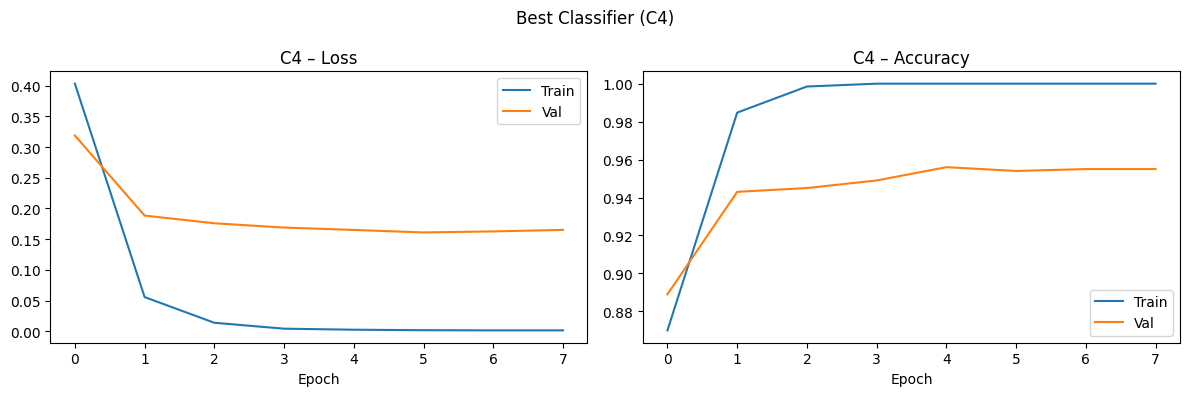

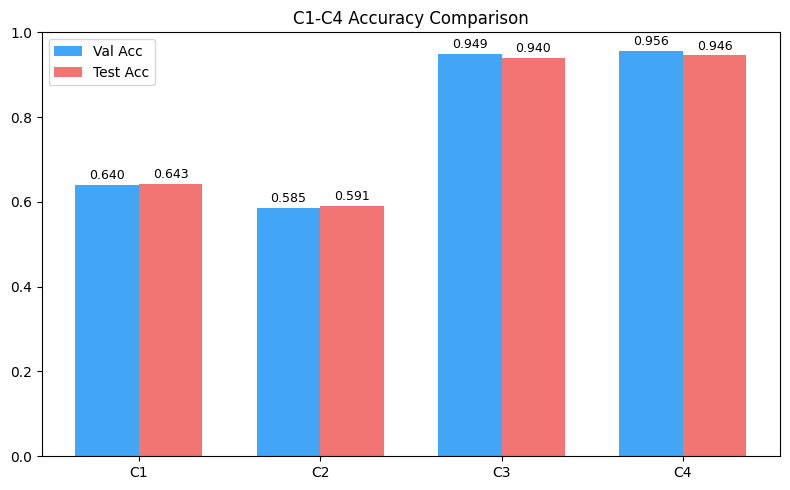

Saved: classification_curves_best.png, classification_compare.png


In [14]:
# График кривых лучшего классификатора
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(bh["train_loss"], label="Train")
ax1.plot(bh["val_loss"],   label="Val")
ax1.set_title(f"{best_exp} – Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(bh["train_acc"], label="Train")
ax2.plot(bh["val_acc"],   label="Val")
ax2.set_title(f"{best_exp} – Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.suptitle(f"Best Classifier ({best_exp})")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "classification_curves_best.png"), dpi=120)
plt.show()

# Сравнительный bar-chart
exps = list(results_a.keys())
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(exps))
w = 0.35
b1 = ax.bar(x - w/2, [results_a[e][1] for e in exps], w, label="Val Acc",  color="#42A5F5")
b2 = ax.bar(x + w/2, [results_a[e][2] for e in exps], w, label="Test Acc", color="#EF5350", alpha=0.8)
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=9)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(exps)
ax.set_ylim(0, 1)
ax.set_title("C1-C4 Accuracy Comparison")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, "classification_compare.png"), dpi=120)
plt.show()
print("Saved: classification_curves_best.png, classification_compare.png")

## 12. Часть B: Сегментация (OxfordIIITPet + DeepLabV3)

### Задача
Используем предобученную модель **DeepLabV3_ResNet50** (обученную на COCO+VOC) для сегментации домашних животных (кошки и собаки) из датасета **OxfordIIITPet**.

### Подход
- Загружаем 20 тестовых изображений с масками переднего плана
- Используем классы COCO: cat=8, dog=12 как foreground
- Сравниваем два варианта постобработки:
  - **V1**: порог threshold=0.5
  - **V2**: порог threshold=0.7 + удаление малых компонент (min_area=200)

### Метрики
- **IoU** (Intersection over Union)
- **Precision** и **Recall** по маске переднего плана

In [15]:
print("\n=== PART B: Segmentation (OxfordIIITPet + DeepLabV3) ===")

# Трансформации для сегментационной модели
tf_img = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Загружаем предобученный DeepLabV3_ResNet50
seg_wts = models.segmentation.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
seg_model = models.segmentation.deeplabv3_resnet50(weights=seg_wts).to(device)
seg_model.eval()
print("DeepLabV3_ResNet50 загружен")

# Классы питомцев в COCO: cat=8, dog=12
PET_COCO = [8, 12]


=== PART B: Segmentation (OxfordIIITPet + DeepLabV3) ===
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\tema/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


DeepLabV3_ResNet50 загружен


## 13. PetSegDataset и инференс

`PetSegDataset` — обёртка над `OxfordIIITPet` с загрузкой масок сегментации.
Маска GT: 1 = передний план (животное), 0/2 = фон.

`segment_image` — инференс DeepLabV3 с применением порога и опциональным удалением малых компонент.

In [16]:
class PetSegDataset(torch.utils.data.Dataset):
    """Загружает OxfordIIITPet с изображением и маской переднего плана."""
    def __init__(self, root, split="test", n_samples=20):
        self.pet = OxfordIIITPet(root, split=split, target_types="segmentation", download=True)
        self.n = min(n_samples, len(self.pet))
        self.tf_img = tf_img

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        img, seg = self.pet[idx]
        img_t   = self.tf_img(img)
        seg_arr = np.array(seg.resize((224, 224), Image.NEAREST))
        # Метка 1 = передний план (животное)
        gt_fg   = (seg_arr == 1).astype(np.uint8)
        return img_t, gt_fg, np.array(img.resize((224, 224)))


ds_pet = PetSegDataset(DATA, split="test", n_samples=20)
print(f"Загружено {len(ds_pet)} изображений OxfordIIITPet (test)")

img_t_ex, gt_ex, img_raw_ex = ds_pet[0]
print(f"Пример: img_t={img_t_ex.shape}, gt_fg={gt_ex.shape}, raw_img={img_raw_ex.shape}")


def segment_image(img_t, threshold=0.5, min_area=None):
    """Запускает DeepLabV3 на одном изображении.
    Возвращает (бинарная маска, вероятность fg).
    """
    with torch.no_grad():
        out = seg_model(img_t.unsqueeze(0).to(device))["out"][0]  # (21, H, W)
    probs  = torch.softmax(out, dim=0)  # (21, 224, 224)
    # Максимальная вероятность по классам питомцев
    fg_prob = probs[PET_COCO].max(0).values.cpu().numpy()
    mask    = (fg_prob > threshold).astype(np.uint8)

    if min_area is not None:
        # BFS поиск связных компонент, удаляем маленькие
        from collections import deque
        labeled   = np.zeros_like(mask, dtype=np.int32)
        visited   = np.zeros_like(mask, dtype=bool)
        comp_id   = 0
        comp_sizes = {}
        for i in range(mask.shape[0]):
            for j in range(mask.shape[1]):
                if mask[i, j] == 1 and not visited[i, j]:
                    comp_id += 1
                    q    = deque([(i, j)])
                    size = 0
                    while q:
                        ci, cj = q.popleft()
                        if ci < 0 or ci >= mask.shape[0] or cj < 0 or cj >= mask.shape[1]:
                            continue
                        if visited[ci, cj] or mask[ci, cj] == 0:
                            continue
                        visited[ci, cj]  = True
                        labeled[ci, cj]  = comp_id
                        size += 1
                        q.extend([(ci+1,cj),(ci-1,cj),(ci,cj+1),(ci,cj-1)])
                    comp_sizes[comp_id] = size
        for cid, sz in comp_sizes.items():
            if sz < min_area:
                mask[labeled == cid] = 0
    return mask, fg_prob

100.0%
100.0%


Загружено 20 изображений OxfordIIITPet (test)
Пример: img_t=torch.Size([3, 224, 224]), gt_fg=(224, 224), raw_img=(224, 224, 3)


## 14. V1 – базовая постобработка (threshold=0.5)

Простейшая постобработка: бинаризация карты вероятностей с порогом 0.5.

In [17]:
print("V1: запускаем инференс (threshold=0.5)...")
masks_v1, gts, raw_imgs = [], [], []
for i in range(len(ds_pet)):
    img_t, gt_fg, img_raw = ds_pet[i]
    m1, _ = segment_image(img_t, threshold=0.5)
    masks_v1.append(m1)
    gts.append(gt_fg)
    raw_imgs.append(img_raw)
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{len(ds_pet)}")
print("V1 готово")

V1: запускаем инференс (threshold=0.5)...
  5/20
  10/20
  15/20
  20/20
V1 готово


## 15. V2 – альтернативная постобработка (threshold=0.7 + удаление малых компонент)

Улучшенная постобработка:
- Повышенный порог бинаризации (0.7) → меньше шума
- Удаление связных компонент площадью < 200 пикселей → убираем артефакты

In [18]:
print("V2: запускаем инференс (threshold=0.7 + min_area=200)...")
masks_v2 = []
for i in range(len(ds_pet)):
    img_t, _, _ = ds_pet[i]
    m2, _ = segment_image(img_t, threshold=0.7, min_area=200)
    masks_v2.append(m2)
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{len(ds_pet)}")
print("V2 готово")

V2: запускаем инференс (threshold=0.7 + min_area=200)...
  5/20
  10/20
  15/20
  20/20
V2 готово


## 16. Метрики сегментации и визуализации

Вычисляем IoU, Precision, Recall для V1 и V2.
Сохраняем:
- `segmentation_examples.png` — примеры сегментации (image, GT, V1, V2)
- `segmentation_metrics.png` — сравнение метрик V1 vs V2

V1 thr=0.5:          mean_IoU=0.7440  prec=0.7552  rec=0.9830
V2 thr=0.7+minarea:  mean_IoU=0.7562  prec=0.8170  rec=0.9218


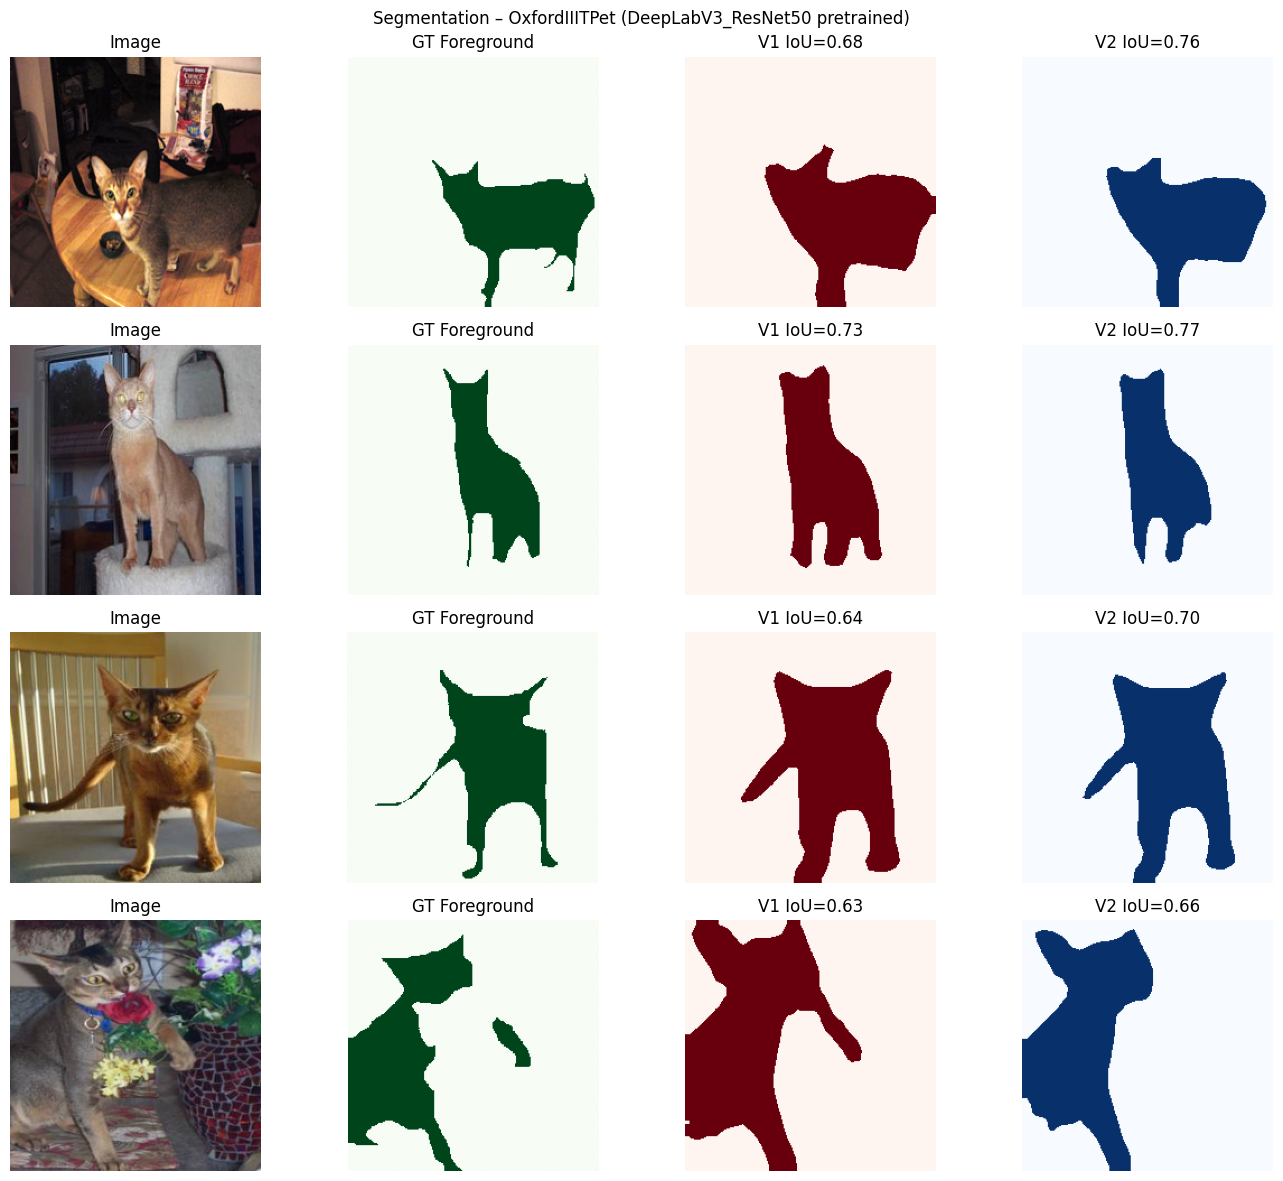

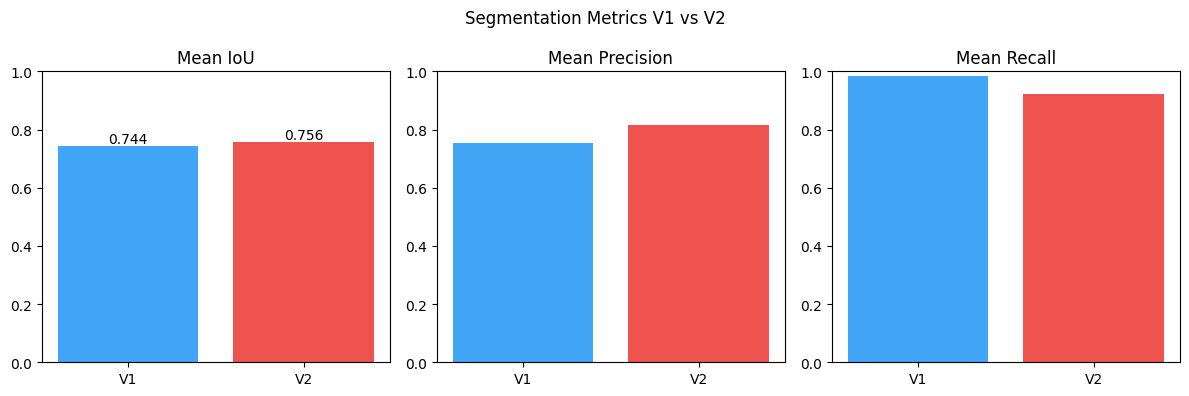

Saved: segmentation_examples.png, segmentation_metrics.png


In [19]:
def iou(pred, gt):
    """Intersection over Union для бинарных масок."""
    p, g   = pred.astype(bool), gt.astype(bool)
    inter  = (p & g).sum()
    union  = (p | g).sum()
    return inter / union if union > 0 else 0.0


def prec_rec(pred, gt):
    """Precision и Recall для бинарных масок."""
    p, g = pred.astype(bool), gt.astype(bool)
    tp   = (p &  g).sum()
    fp   = (p & ~g).sum()
    fn   = (~p & g).sum()
    pr   = tp / (tp + fp) if tp + fp > 0 else 0.0
    rc   = tp / (tp + fn) if tp + fn > 0 else 0.0
    return pr, rc


# Вычисляем метрики
ious_v1 = [iou(m, g)      for m, g in zip(masks_v1, gts)]
ious_v2 = [iou(m, g)      for m, g in zip(masks_v2, gts)]
prs_v1  = [prec_rec(m, g) for m, g in zip(masks_v1, gts)]
prs_v2  = [prec_rec(m, g) for m, g in zip(masks_v2, gts)]

miou_v1  = np.mean(ious_v1)
miou_v2  = np.mean(ious_v2)
mprec_v1 = np.mean([p for p, r in prs_v1])
mrec_v1  = np.mean([r for p, r in prs_v1])
mprec_v2 = np.mean([p for p, r in prs_v2])
mrec_v2  = np.mean([r for p, r in prs_v2])

print(f"V1 thr=0.5:          mean_IoU={miou_v1:.4f}  prec={mprec_v1:.4f}  rec={mrec_v1:.4f}")
print(f"V2 thr=0.7+minarea:  mean_IoU={miou_v2:.4f}  prec={mprec_v2:.4f}  rec={mrec_v2:.4f}")

# Визуализация примеров сегментации
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for row in range(4):
    axes[row, 0].imshow(raw_imgs[row])
    axes[row, 0].set_title("Image")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(gts[row], cmap="Greens", vmin=0, vmax=1)
    axes[row, 1].set_title("GT Foreground")
    axes[row, 1].axis("off")
    axes[row, 2].imshow(masks_v1[row], cmap="Reds", vmin=0, vmax=1)
    axes[row, 2].set_title(f"V1 IoU={ious_v1[row]:.2f}")
    axes[row, 2].axis("off")
    axes[row, 3].imshow(masks_v2[row], cmap="Blues", vmin=0, vmax=1)
    axes[row, 3].set_title(f"V2 IoU={ious_v2[row]:.2f}")
    axes[row, 3].axis("off")
plt.suptitle("Segmentation – OxfordIIITPet (DeepLabV3_ResNet50 pretrained)")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "segmentation_examples.png"), dpi=100)
plt.show()

# График метрик V1 vs V2
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].bar(["V1", "V2"], [miou_v1, miou_v2], color=["#42A5F5", "#EF5350"])
axes[0].set_title("Mean IoU")
axes[0].set_ylim(0, 1)
for h in axes[0].patches:
    axes[0].text(h.get_x() + h.get_width()/2, h.get_height() + 0.01,
                 f"{h.get_height():.3f}", ha="center", fontsize=10)

axes[1].bar(["V1", "V2"], [mprec_v1, mprec_v2], color=["#42A5F5", "#EF5350"])
axes[1].set_title("Mean Precision")
axes[1].set_ylim(0, 1)

axes[2].bar(["V1", "V2"], [mrec_v1, mrec_v2], color=["#42A5F5", "#EF5350"])
axes[2].set_title("Mean Recall")
axes[2].set_ylim(0, 1)

plt.suptitle("Segmentation Metrics V1 vs V2")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "segmentation_metrics.png"), dpi=120)
plt.show()
print("Saved: segmentation_examples.png, segmentation_metrics.png")

## 17. Сохранение артефактов (runs.csv)

Сохраняем сводную таблицу всех экспериментов (C1-C4 и V1-V2) в `artifacts/runs.csv`.

Колонки:
- `experiment_id`, `task`, `dataset`, `seed`, `model_summary`
- `optimizer`, `lr`, `epochs_trained`
- `best_val_accuracy`, `test_accuracy` (для классификации)
- `precision`, `recall`, `mean_iou` (для сегментации)
- `notes`

In [20]:
model_names = {
    "C1": "SimpleCNN-base",
    "C2": "SimpleCNN-aug",
    "C3": "ResNet18-head-only",
    "C4": "ResNet18-finetune",
}
lrs_map = {"C1": 1e-3, "C2": 1e-3, "C3": 1e-3, "C4": 5e-4}

rows = []

# Строки для классификационных экспериментов
for exp_id in ["C1", "C2", "C3", "C4"]:
    h, v, t = results_a[exp_id][:3]
    rows.append(dict(
        experiment_id    = exp_id,
        task             = "classification",
        dataset          = "STL10",
        seed             = SEED,
        model_summary    = model_names[exp_id],
        optimizer        = "Adam",
        lr               = lrs_map[exp_id],
        epochs_trained   = EPOCHS_A,
        best_val_accuracy= round(v, 4),
        test_accuracy    = round(t, 4),
        precision        = "",
        recall           = "",
        mean_iou         = "",
        notes            = "",
    ))

# Строки для сегментационных экспериментов
for vi, thr, note in [
    ("V1", 0.5,              "threshold=0.5"),
    ("V2", "0.7+minarea200", "threshold=0.7+minarea200"),
]:
    mio = miou_v1  if vi == "V1" else miou_v2
    mpr = mprec_v1 if vi == "V1" else mprec_v2
    mrc = mrec_v1  if vi == "V1" else mrec_v2
    rows.append(dict(
        experiment_id    = vi,
        task             = "segmentation",
        dataset          = "OxfordIIITPet",
        seed             = SEED,
        model_summary    = "DeepLabV3_ResNet50(COCO_WITH_VOC_LABELS_V1)",
        optimizer        = "",
        lr               = "",
        epochs_trained   = "",
        best_val_accuracy= "",
        test_accuracy    = "",
        precision        = round(mpr, 4),
        recall           = round(mrc, 4),
        mean_iou         = round(mio, 4),
        notes            = note,
    ))

# Сохраняем CSV
csv_path = os.path.join(ART, "runs.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved runs.csv → {csv_path}")
print("\nСводная таблица:")
print(f"{'Exp':5} | {'Task':15} | {'Val/IoU':>8} | {'Test/Prec':>9} | Notes")
print("-" * 65)
for row in rows:
    if row["task"] == "classification":
        print(f"{row['experiment_id']:5} | {row['task']:15} | {row['best_val_accuracy']:>8} | {row['test_accuracy']:>9} | {row['notes']}")
    else:
        print(f"{row['experiment_id']:5} | {row['task']:15} | {row['mean_iou']:>8} | {row['precision']:>9} | {row['notes']}")

print("\n✓ HW10-11 выполнен!")

Saved runs.csv → c:\Users\tema\nano-banana\homeworks\HW10-11\artifacts\runs.csv

Сводная таблица:
Exp   | Task            |  Val/IoU | Test/Prec | Notes
-----------------------------------------------------------------
C1    | classification  |     0.64 |    0.6429 | 
C2    | classification  |    0.585 |    0.5914 | 
C3    | classification  |    0.949 |    0.9397 | 
C4    | classification  |    0.956 |    0.9459 | 
V1    | segmentation    |    0.744 |    0.7552 | threshold=0.5
V2    | segmentation    |   0.7562 |     0.817 | threshold=0.7+minarea200

✓ HW10-11 выполнен!
